# Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
#import itertoolsza

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

# Modeling Weekly Rat Sightings in Staten Island

## Importing the Data

In [2]:
# set up the time series split
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=30, test_size=4)


rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-06 and after 2025-03-02.
rs = rs[rs['created_date'].between('2020-01-06', '2025-03-02')] #changed dates slightly to obtain whole weeks. Monday - Sunday

## Restrict to STATEN ISLAND

rs = rs[rs['borough']=='STATEN ISLAND']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

rs

,created_date,count
27,2020-01-06,4
32,2020-01-07,2
41,2020-01-09,1
54,2020-01-12,2
59,2020-01-13,3
...,...,...
8907,2025-02-24,3
8912,2025-02-25,1
8917,2025-02-26,1
8926,2025-02-28,2


  created_date  weekly_sum
0   2020-01-12           9
1   2020-01-19           9
2   2020-01-26           4
3   2020-02-02           8
4   2020-02-09           6
5   2020-02-16          12
6   2020-02-23          10
7   2020-03-01          12
8   2020-03-08           4
9   2020-03-15          16

Shape: (269, 2)
Date range: 2020-01-12 00:00:00 → 2025-03-02 00:00:00

--- Summary Statistics ---
count    269.00
mean      12.76
std        7.35
min        0.00
25%        7.00
50%       12.00
75%       18.00
max       49.00
Name: weekly_sum, dtype: float64


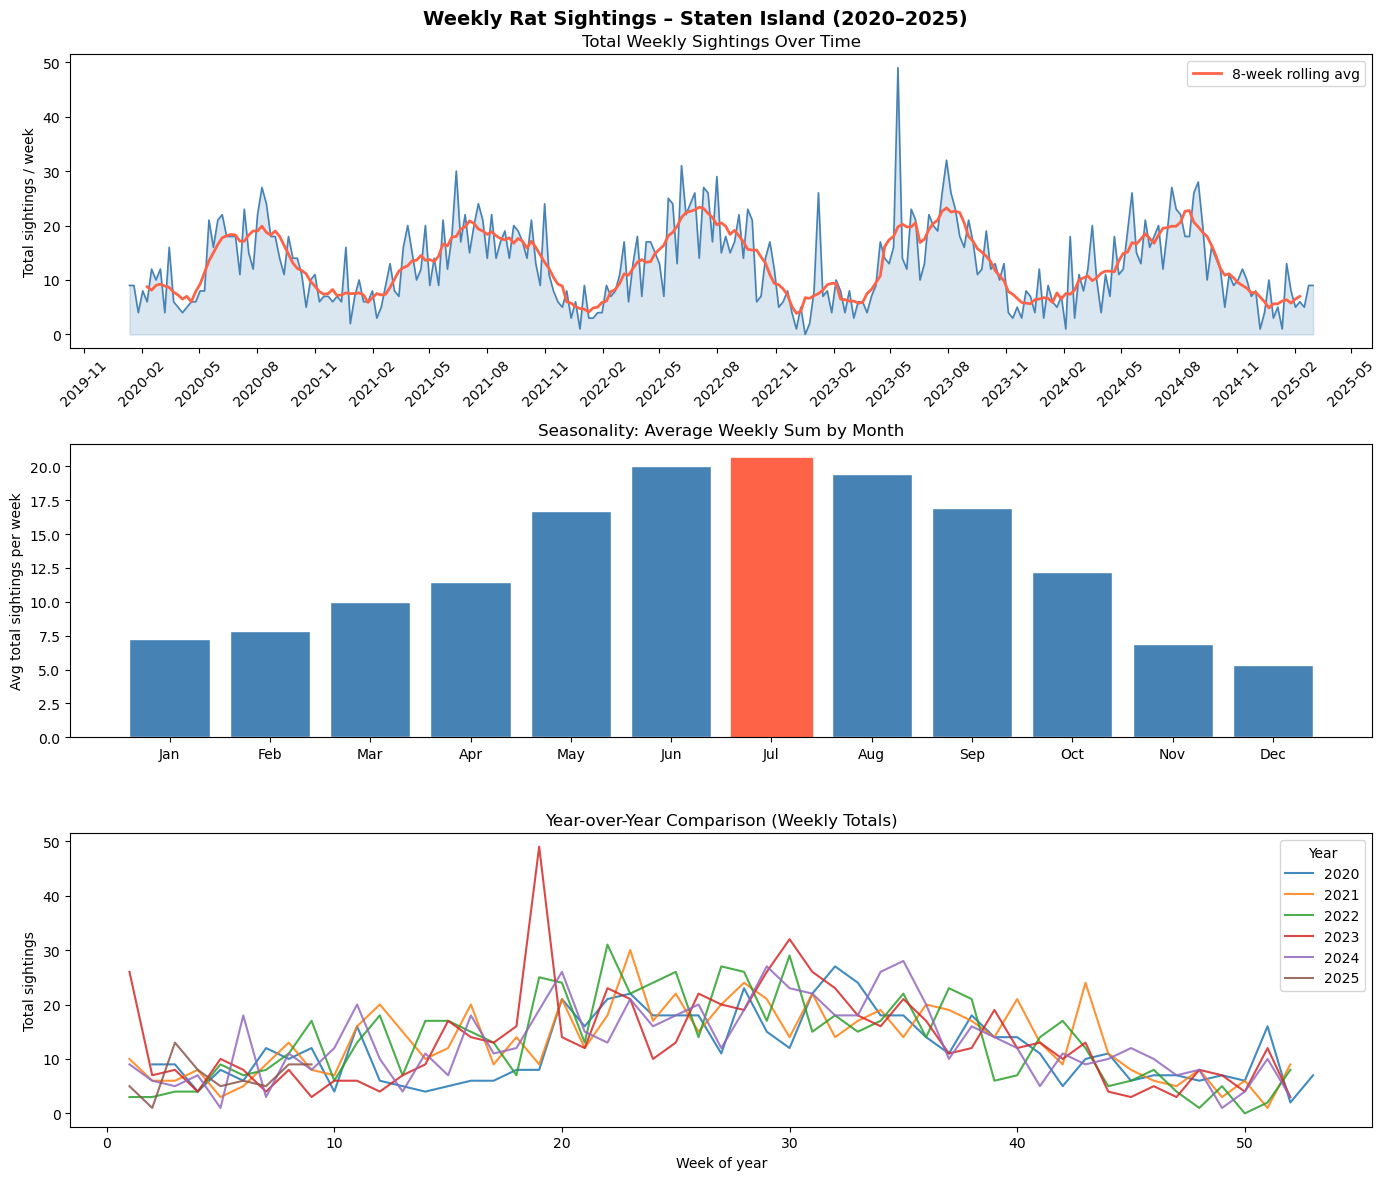


--- Year-over-Year Averages of Weekly Sums ---
       mean  median  max  min
year                         
2020  11.90    11.0   27    2
2021  13.31    13.5   30    1
2022  13.42    13.5   31    0
2023  13.19    12.0   49    3
2024  13.00    12.0   28    1
2025   6.78     6.0   13    1


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Weekly resampling (Changed .mean() to .sum()) ---
rs_weekly = (
    rs.set_index('created_date')
      .resample('W')['count']
      .sum()
      .fillna(0)
      .reset_index()
      .rename(columns={'count': 'weekly_sum'})
)

print(rs_weekly.head(10))
print(f"\nShape: {rs_weekly.shape}")
print(f"Date range: {rs_weekly['created_date'].min()} → {rs_weekly['created_date'].max()}")
print("\n--- Summary Statistics ---")
print(rs_weekly['weekly_sum'].describe().round(2))

# --- Add time features ---
rs_weekly['year']  = rs_weekly['created_date'].dt.year
rs_weekly['month'] = rs_weekly['created_date'].dt.month
rs_weekly['week_of_year'] = rs_weekly['created_date'].dt.isocalendar().week.astype(int)
rs_weekly['iso_year'] = rs_weekly['created_date'].dt.isocalendar().year.astype(int)  

# --- Plot 1: Full time series ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Weekly Rat Sightings – Staten Island (2020–2025)', fontsize=14, fontweight='bold')

ax = axes[0]
# Updated from weekly_avg to weekly_sum
ax.plot(rs_weekly['created_date'], rs_weekly['weekly_sum'], color='steelblue', linewidth=1.2)
ax.fill_between(rs_weekly['created_date'], rs_weekly['weekly_sum'], alpha=0.2, color='steelblue')

# Updated rolling window to use weekly_sum
rolling = rs_weekly['weekly_sum'].rolling(8, center=True).mean()
ax.plot(rs_weekly['created_date'], rolling, color='tomato', linewidth=2, label='8-week rolling avg')

ax.set_title('Total Weekly Sightings Over Time')
ax.set_ylabel('Total sightings / week')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 2: Seasonality ---
ax2 = axes[1]
# Calculating the average of the weekly sums for each month
monthly_avg = rs_weekly.groupby('month')['weekly_sum'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bars = ax2.bar(month_names, monthly_avg.values, color='steelblue', edgecolor='white')
ax2.set_title('Seasonality: Average Weekly Sum by Month')
ax2.set_ylabel('Avg total sightings per week')
bars[monthly_avg.idxmax() - 1].set_color('tomato')

# --- Plot 3: Year-over-year ---
ax3 = axes[2]
for year, grp in rs_weekly.groupby('iso_year'):
    grp = grp.sort_values('week_of_year')
    # Updated from weekly_avg to weekly_sum
    ax3.plot(grp['week_of_year'], grp['weekly_sum'], label=str(year), linewidth=1.5, alpha=0.85)

ax3.set_title('Year-over-Year Comparison (Weekly Totals)')
ax3.set_xlabel('Week of year')
ax3.set_ylabel('Total sightings')
ax3.legend(title='Year')

plt.tight_layout()
plt.savefig('rat_sightings_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Year-over-Year Averages of Weekly Sums ---")
print(rs_weekly.groupby('year')['weekly_sum'].agg(['mean','median','max','min']).round(2))

In [4]:
## There are 269 weeks from 2020-01-05 to 2025-03-02 inclusive. Confirm we have the correct number.
#rs_weekly.tail()
len(rs_weekly)

269

## Baseline Seasonal Average Model

In [5]:
years_back_use = 4
week_window_use = 1



In [ ]:
def seasonal_average_forecast_weekly(data, target_dates, years_back=3, week_window=1):
    """
    Predicts the weekly sum by looking at the same week in previous years.
    """
    predictions = []
    
    for date in target_dates:
        # Get the ISO week and year for the target date
        target_week = date.isocalendar().week
        target_year = date.isocalendar().year
        
        # Define the range of years to look back
        years_to_check = range(target_year - years_back, target_year)
        
        # Define the window of weeks (e.g., if window=1, look at weeks 51, 52, 1)
        weeks_to_check = range(target_week - week_window, target_week + week_window + 1)
        
        # Filter the training data
        # --- Changed 'weekly_avg' to 'weekly_sum' ---
        past_values = data[
            (data['iso_year'].isin(years_to_check)) & 
            (data['week_of_year'].isin(weeks_to_check))
        ]['weekly_sum'] 
        
        # If no data found for those weeks, default to 0 (or the overall mean)
        if len(past_values) > 0:
            predictions.append(past_values.mean())
        else:
            predictions.append(0)
            
    return np.array(predictions)

In [ ]:
results = []

rs_weekly["created_date"] = pd.to_datetime(rs_weekly["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index].copy()
    test = rs_weekly.iloc[test_index].copy()
    
    # Target dates = the weeks we want to forecast
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data
    y_pred = seasonal_average_forecast_weekly(data=train, target_dates=target_dates, 
                                              years_back=years_back_use, week_window=week_window_use)

    # --- Change "weekly_avg" to "weekly_sum" ---
    y_true = test["weekly_sum"].values 
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({"fold": i, "rmse": rmse, "mape": mape})

baseline_results_weekly_df = pd.DataFrame(results)
# Using .iloc to calculate means to avoid potential index/column name conflicts during the append
baseline_results_weekly_df.loc["mean"] = ["mean", baseline_results_weekly_df["rmse"].mean(), baseline_results_weekly_df["mape"].mean()]

baseline_results_weekly_df.head()

,fold,rmse,mape
0,0,2.936835,1.503125e+00
1,1,10.689572,7.318349e+15
2,2,2.523692,3.247024e-01
3,3,4.497942,9.918981e-01
4,4,6.248457,1.159392e+00


## Year Ago Rolling 4 Week Average 

In [ ]:
rs_weekly.rename(columns={'created_date': 'ds', 'weekly_avg': 'y'}, inplace=True)

## saving a copy for later
rs_weekly_saved = rs_weekly.copy()

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for fold, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index].copy()
    test = rs_weekly.iloc[test_index].copy()

    # --- Ensure we are sorting by the date, whether it's a column or index ---
    # We use sort_index() if the date is the index, or sort_values if it's a column.
    if 'created_date' in train.columns:
        train_sorted = train.sort_values('created_date')
    else:
        # Fallback: if created_date is the index, sort by index
        train_sorted = train.sort_index()

    # --- Use the actual column name for y ---
    # If your column is 'weekly_sum', this will work. 
    train_sorted['rolling_4w'] = train_sorted['weekly_sum'].rolling(window=4, min_periods=1).mean()

    y_true = test['weekly_sum'].values
    last_rolling_avg = train_sorted['rolling_4w'].iloc[-1]
    
    # Fill predictions with the last known rolling average
    y_pred = np.full(len(y_true), last_rolling_avg)
        
    fold_rmse = rmse(y_true, y_pred)
    fold_mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': fold, 'rmse': fold_rmse, 'mape': fold_mape})

rolling4w_weekly_results_df = pd.DataFrame(results)

# Append mean row
overall_rmse = rolling4w_weekly_results_df['rmse'].mean()
overall_mape = rolling4w_weekly_results_df['mape'].mean()
rolling4w_weekly_results_df.loc['mean'] = ['mean', overall_rmse, overall_mape]

print("--- Rolling 4-Week Baseline Results ---")
print(rolling4w_weekly_results_df)

--- Rolling 4-Week Baseline Results ---
      fold       rmse          mape
0        0   6.041523  2.937500e+00
1        1  11.191515  5.066550e+15
2        2   2.783882  4.401786e-01
3        3   2.727178  6.041667e-01
4        4   1.089725  1.748512e-01
5        5   8.027297  5.424635e-01
6        6  17.942617  2.648012e-01
7        7   8.073878  5.298007e-01
8        8   5.673403  2.188317e-01
9        9   5.889609  1.866138e-01
10      10   9.216154  6.078322e-01
11      11   3.682730  2.757675e-01
12      12   7.713624  1.660897e+00
13      13   2.598076  5.334821e-01
14      14   3.881044  5.590278e-01
15      15   3.201562  1.641667e+00
16      16   7.553972  5.734691e-01
17      17   5.916080  5.416667e-01
18      18   3.968627  2.737193e-01
19      19   8.158584  2.917890e-01
20      20   3.082207  1.631181e-01
21      21   5.873670  2.605750e-01
22      22   2.397916  1.081192e-01
23      23   7.040064  3.838599e-01
24      24  10.136567  1.190625e+00
25      25   1.677051  1

In [10]:
rolling4w_weekly_results_df.head()

,fold,rmse,mape
0,0,6.041523,2.937500e+00
1,1,11.191515,5.066550e+15
2,2,2.783882,4.401786e-01
3,3,2.727178,6.041667e-01
4,4,1.089725,1.748512e-01


## Prophet Model

In [11]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-06", end="2025-03-02")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Snap each holiday to the nearest week-ending Sunday (to match rs_weekly's 'ds' format)
holidays_weekly = pd.to_datetime(holidays).to_series().apply(
    lambda d: d + pd.offsets.Week(weekday=6) if d.weekday() != 6 else d
).reset_index(drop=True)

# Build the DataFrame
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': holidays_weekly,
    'lower_window': 0,
    'upper_window': 1,
})

# Drop duplicate weeks (two holidays can fall in the same week)
federal_holidays = federal_holidays.drop_duplicates(subset='ds')

holidays = federal_holidays

In [12]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index].copy()
    test  = rs_weekly.iloc[test_index].copy()

    # Prophet requires 'ds' and 'y' columns
    train = train.rename(columns={'created_date': 'ds', 'weekly_sum': 'y'})
    test  = test.rename(columns={'created_date': 'ds', 'weekly_sum': 'y'})

    # Fresh model each fold
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)

    future   = model.make_future_dataframe(periods=len(test), freq='W')
    forecast = model.predict(future)

    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values

    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)

    results.append({'fold': i, 'rmse': rmse_val, 'mape': mape_val})

prophet_weekly_results_df = pd.DataFrame(results)

23:31:39 - cmdstanpy - INFO - Chain [1] start processing
23:31:39 - cmdstanpy - INFO - Chain [1] done processing
23:31:39 - cmdstanpy - INFO - Chain [1] start processing
23:31:39 - cmdstanpy - INFO - Chain [1] done processing
23:31:39 - cmdstanpy - INFO - Chain [1] start processing
23:31:40 - cmdstanpy - INFO - Chain [1] done processing
23:31:40 - cmdstanpy - INFO - Chain [1] start processing
23:31:40 - cmdstanpy - INFO - Chain [1] done processing
23:31:40 - cmdstanpy - INFO - Chain [1] start processing
23:31:40 - cmdstanpy - INFO - Chain [1] done processing
23:31:40 - cmdstanpy - INFO - Chain [1] start processing
23:31:40 - cmdstanpy - INFO - Chain [1] done processing
23:31:40 - cmdstanpy - INFO - Chain [1] start processing
23:31:40 - cmdstanpy - INFO - Chain [1] done processing
23:31:40 - cmdstanpy - INFO - Chain [1] start processing
23:31:40 - cmdstanpy - INFO - Chain [1] done processing
23:31:40 - cmdstanpy - INFO - Chain [1] start processing
23:31:40 - cmdstanpy - INFO - Chain [1]

In [13]:
prophet_weekly_results_df.loc['mean'] = {
    'fold': 'mean',
    'rmse': prophet_weekly_results_df['rmse'].mean(),
    'mape': prophet_weekly_results_df['mape'].mean()
}

In [14]:
prophet_weekly_results_df.head()

,fold,rmse,mape
0,0,4.603081,2.337669e+00
1,1,10.025632,8.453369e+15
2,2,2.685939,3.895537e-01
3,3,6.625335,1.484722e+00
4,4,7.093459,1.313078e+00


## SARIMA Model with auto_arima parameters.

In [15]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [16]:
from pmdarima import auto_arima

In [17]:
def fourier_terms(df, period, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for i in range(1, n_terms + 1):
        fourier_df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        fourier_df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

In [18]:
# Number of Fourier terms and period (52 for yearly seasonality)
n_terms = 5  # Number of terms for Fourier Terms
period = 52 

In [19]:
# Generate Fourier terms and putting it into a list
fourier_train = fourier_terms(rs, period, n_terms)

# Name it exog since it will serve as exogenous features for SARIMAX. This is the X.
exog = fourier_train

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Normalize rs_weekly — handle whatever column name the date ended up as
_date_col = next((c for c in ['created_date', 'ds'] if c in rs_weekly.columns), None)

if _date_col is None:
    raise ValueError(f"No date column found. Columns present: {rs_weekly.columns.tolist()}")

rs_weekly_indexed = (
    rs_weekly
    .rename(columns={_date_col: 'created_date'})   # standardize name
    .set_index('created_date')
    .copy()
)
rs_weekly_indexed.index = pd.to_datetime(rs_weekly_indexed.index)
rs_weekly_indexed = rs_weekly_indexed.asfreq('W').fillna(0)

assert rs_weekly_indexed.shape[0] > 0, "rs_weekly_indexed is empty after asfreq — check source data"
assert 'weekly_sum' in rs_weekly_indexed.columns, \
    f"'weekly_sum' not found. Columns: {rs_weekly_indexed.columns.tolist()}"

print(f"Ready: {rs_weekly_indexed.shape[0]} weeks | "
      f"{rs_weekly_indexed.index.min().date()} → {rs_weekly_indexed.index.max().date()}")

# 2. Align exog to the same index
exog_reindexed = exog.reindex(rs_weekly_indexed.index).fillna(0)

# 3. Cross-validation
orders          = (2, 1, 3)
seasonal_orders = (0, 0, 0, 0)
results         = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly_indexed)):
    train = rs_weekly_indexed.iloc[train_index]
    test  = rs_weekly_indexed.iloc[test_index]

    exog_train = exog_reindexed.iloc[train_index]
    exog_test  = exog_reindexed.iloc[test_index]

    model_sarimax = SARIMAX(
        np.log1p(train['weekly_sum']),
        order=orders,
        seasonal_order=seasonal_orders,
        exog=exog_train,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    model_fit = model_sarimax.fit(disp=False, maxiter=200)

    y_pred = np.expm1(
        model_fit.get_forecast(steps=len(test), exog=exog_test).predicted_mean
    )
    y_true = test['weekly_sum'].values

    # Guard against zero y_true values poisoning MAPE
    nonzero = y_true != 0
    mape_val = (mean_absolute_percentage_error(y_true[nonzero], y_pred[nonzero])
                if nonzero.sum() > 0 else np.nan)

    results.append({
        'fold': i,
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mape_val
    })

# 4. Summary
sarima_weekly_results_df = pd.DataFrame(results)
sarima_weekly_results_df.loc['mean'] = {
    'fold': 'mean',
    'rmse': sarima_weekly_results_df['rmse'].mean(),
    'mape': sarima_weekly_results_df['mape'].mean()
}

print(sarima_weekly_results_df)

Ready: 269 weeks | 2020-01-12 → 2025-03-02
      fold       rmse      mape
0        0   3.179456  1.626924
1        1  12.221369  0.583901
2        2   3.043612  0.457169
3        3   2.220299  0.441928
4        4   1.651062  0.277837
5        5   9.272550  0.640975
6        6  17.551563  0.249618
7        7   7.047532  0.451915
8        8   8.750686  0.373330
9        9   5.694338  0.177755
10      10   5.929877  0.368472
11      11   2.913173  0.199898
12      12   7.294606  1.564642
13      13   2.634734  0.384052
14      14   3.654545  0.619473
15      15   2.725790  1.412553
16      16   8.595386  0.554232
17      17   6.869216  0.591941
18      18   5.813102  0.311536
19      19   8.368386  0.305877
20      20   2.962836  0.159365
21      21   5.754137  0.259762
22      22   2.827031  0.132277
23      23   7.166230  0.381723
24      24   5.993749  0.696153
25      25   2.044418  0.152309
26      26   5.280310  2.609498
27      27   3.215204  0.297552
28      28   4.873651  1.1912

In [21]:
sarima_weekly_results_df.loc['mean'] = {
    'fold': 'mean',
    'rmse': sarima_weekly_results_df['rmse'].mean(),
    'mape': sarima_weekly_results_df['mape'].mean()
}

print(sarima_weekly_results_df)

      fold       rmse      mape
0        0   3.179456  1.626924
1        1  12.221369  0.583901
2        2   3.043612  0.457169
3        3   2.220299  0.441928
4        4   1.651062  0.277837
5        5   9.272550  0.640975
6        6  17.551563  0.249618
7        7   7.047532  0.451915
8        8   8.750686  0.373330
9        9   5.694338  0.177755
10      10   5.929877  0.368472
11      11   2.913173  0.199898
12      12   7.294606  1.564642
13      13   2.634734  0.384052
14      14   3.654545  0.619473
15      15   2.725790  1.412553
16      16   8.595386  0.554232
17      17   6.869216  0.591941
18      18   5.813102  0.311536
19      19   8.368386  0.305877
20      20   2.962836  0.159365
21      21   5.754137  0.259762
22      22   2.827031  0.132277
23      23   7.166230  0.381723
24      24   5.993749  0.696153
25      25   2.044418  0.152309
26      26   5.280310  2.609498
27      27   3.215204  0.297552
28      28   4.873651  1.191286
29      29   2.016335  0.229152
mean  me

In [22]:
sarima_weekly_results_df.head()

,fold,rmse,mape
0,0,3.179456,1.626924
1,1,12.221369,0.583901
2,2,3.043612,0.457169
3,3,2.220299,0.441928
4,4,1.651062,0.277837


## Holt-Winters Model

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    # --- Changed 'y' to 'weekly_sum' ---
    holt_winters = ExponentialSmoothing(
        train['weekly_sum'], 
        seasonal='add', 
        seasonal_periods=52
    ).fit(optimized=True)
    
    y_pred = holt_winters.forecast(len(test))
    
    # --- Changed 'y' to 'weekly_sum' ---
    y_true = test['weekly_sum'].values
    
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse_val, 'mape': mape_val})

hw_weekly_results_df = pd.DataFrame(results)

# Append the mean row using the dictionary fix to avoid length errors
hw_weekly_results_df.loc['mean'] = {
    'fold': 'mean',
    'rmse': hw_weekly_results_df['rmse'].mean(),
    'mape': hw_weekly_results_df['mape'].mean()
}

print(hw_weekly_results_df)

      fold       rmse          mape
0        0   3.745736  1.947859e+00
1        1  10.636795  1.277266e+16
2        2   2.967417  4.065473e-01
3        3   5.459645  1.193625e+00
4        4   6.549517  1.161926e+00
5        5   3.820686  2.124955e-01
6        6  16.060629  4.379612e-01
7        7   6.714707  4.497937e-01
8        8   6.716407  2.649825e-01
9        9   6.105216  1.912042e-01
10      10   5.190844  3.167980e-01
11      11   4.839088  2.776934e-01
12      12   3.091215  6.429502e-01
13      13   2.266910  4.333317e-01
14      14   6.162162  9.236011e-01
15      15   3.054198  1.571131e+00
16      16   5.535401  5.347222e-01
17      17   5.629166  4.989587e-01
18      18   3.697554  2.960382e-01
19      19   5.059026  1.857750e-01
20      20   5.429955  2.665934e-01
21      21   7.044512  3.753908e-01
22      22   1.211983  5.746585e-02
23      23   8.025255  4.232491e-01
24      24   3.169714  3.415236e-01
25      25   4.596177  3.905300e-01
26      26   3.184375  1.301

In [25]:
hw_weekly_results_df.loc['mean'] = ['mean',  hw_weekly_results_df['rmse'].mean(), hw_weekly_results_df['mape'].mean()]

In [26]:
hw_weekly_results_df.head()

,fold,rmse,mape
0,0,3.745736,1.947859e+00
1,1,10.636795,1.277266e+16
2,2,2.967417,4.065473e-01
3,3,5.459645,1.193625e+00
4,4,6.549517,1.161926e+00


## XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs is quite bare. We will need to add features for use.

In [27]:
import xgboost as xgb
from xgboost import plot_importance


In [28]:
rs_weekly.head()

,ds,weekly_sum,year,month,week_of_year,iso_year
0,2020-01-12,9,2020,1,2,2020
1,2020-01-19,9,2020,1,3,2020
2,2020-01-26,4,2020,1,4,2020
3,2020-02-02,8,2020,2,5,2020
4,2020-02-09,6,2020,2,6,2020


### Adding Features to XGBoost

In [ ]:
def create_features(df):
    df = df.copy()
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    # Convert to int to ensure sine/cosine math works correctly
    df['weekofyear'] = df.index.isocalendar().week.astype(int)
    return df

def add_cyclic(df):
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    df['week_sin'] = np.sin(2 * np.pi * df['weekofyear']/52)
    df['week_cos'] = np.cos(2 * np.pi * df['weekofyear']/52)
    return df

def add_lags(df):
    # --- Changed 'y' to 'weekly_sum' ---
    target_map = df['weekly_sum'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('7 days')).map(target_map)    # 1 week ago
    df['lag2'] = (df.index - pd.Timedelta('14 days')).map(target_map)   # 2 weeks ago
    df['lag3'] = (df.index - pd.Timedelta('21 days')).map(target_map)   # 3 weeks ago
    df['lag4'] = (df.index - pd.Timedelta('28 days')).map(target_map)   # 4 weeks ago
    df['lag5'] = (df.index - pd.Timedelta('35 days')).map(target_map)   # 5 weeks ago
    df['lag6'] = (df.index - pd.Timedelta('42 days')).map(target_map)   # 6 weeks ago
    df['lag7'] = (df.index - pd.Timedelta('49 days')).map(target_map)   # 7 weeks ago
    df['lag8'] = (df.index - pd.Timedelta('56 days')).map(target_map)   # 8 weeks ago
    return df

def add_seasonal_lags(df):
    # --- Changed 'y' to 'weekly_sum' ---
    target_map = df['weekly_sum'].to_dict()
    df['lag13']  = (df.index - pd.Timedelta('91 days')).map(target_map)   # ~1 quarter ago
    df['lag26']  = (df.index - pd.Timedelta('182 days')).map(target_map)  # ~6 months ago
    df['lag52']  = (df.index - pd.Timedelta('364 days')).map(target_map)  # ~1 year ago
    df['lag104'] = (df.index - pd.Timedelta('728 days')).map(target_map)  # ~2 years ago
    df['lag156'] = (df.index - pd.Timedelta('1092 days')).map(target_map) # ~3 years ago
    df['lag208'] = (df.index - pd.Timedelta('1456 days')).map(target_map) # ~4 years ago
    df['lag260'] = (df.index - pd.Timedelta('1820 days')).map(target_map) # ~5 years ago
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    # --- Changed 'y' to 'weekly_sum' ---
    # .shift(1) is critical here to avoid data leakage (using today's sum to predict today)
    df['ma4']  = df['weekly_sum'].shift(1).rolling(window=4).mean()   # 1 month
    df['ma8']  = df['weekly_sum'].shift(1).rolling(window=8).mean()   # 2 months
    df['ma13'] = df['weekly_sum'].shift(1).rolling(window=13).mean()  # 1 quarter
    df['ma26'] = df['weekly_sum'].shift(1).rolling(window=26).mean()  # 6 months
    df['ma52'] = df['weekly_sum'].shift(1).rolling(window=52).mean()  # 1 year
    return df

In the next two code block, we add weather data to the data set. This is not optimized i.e. we just obtain the weather data in Staten Island and hope that it is representative of the average weather over the whole city.

In [30]:
import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    # Fallback to local data if API fails
    nd = pd.read_csv("weatherdata.csv")
    nd["date"] = pd.to_datetime(nd['date']) # Ensure date is datetime
    nd = nd.set_index('date')
    wd_daily = nd
else:
    wd_daily = pd.DataFrame(data["daily"])
    wd_daily["date"] = pd.to_datetime(wd_daily["time"])
    wd_daily = wd_daily.set_index("date")

# --- Resample to weekly (matching the 'W' frequency of rs_weekly) ---
# This aggregates the daily weather into metrics that describe the whole week
wd = wd_daily.resample('W').agg({
    'temperature_2m_max':          'max',   # The extreme heat of that week
    'temperature_2m_min':          'min',   # The extreme cold of that week
    'temperature_2m_mean':         'mean',  # General thermal trend of the week
    'apparent_temperature_max':    'max',
    'apparent_temperature_min':    'min',
    'apparent_temperature_mean':   'mean',
    'precipitation_sum':           'sum',   # Total weekly rain (high totals = more rats?)
    'snowfall_sum':                'sum',   # Total weekly snow
})

# Rename columns to reflect they are weekly aggregates (optional but recommended)
wd.columns = [f"weekly_{col}" for col in wd.columns]

print(f"Weather data shape: {wd.shape}")
print(wd.head())

Weather data shape: (270, 8)
            weekly_temperature_2m_max  weekly_temperature_2m_min  \
date                                                               
2020-01-05                        9.6                       -2.1   
2020-01-12                       18.5                       -5.2   
2020-01-19                        9.1                       -6.3   
2020-01-26                       10.1                       -7.2   
2020-02-02                        7.4                       -5.7   

            weekly_temperature_2m_mean  weekly_apparent_temperature_max  \
date                                                                      
2020-01-05                    4.340000                              7.9   
2020-01-12                    5.357143                             15.0   
2020-01-19                    2.314286                              7.8   
2020-01-26                    0.257143                              6.7   
2020-02-02                    1.714286      

In [31]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary column from weather data
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
        
    # Find columns that are present in both df and wd
    overlapping_cols = df.columns.intersection(wd.columns)
    
    if not overlapping_cols.empty:
        # If columns already exist, update them with the latest data from wd
        df.update(wd)
    else:
        # If columns don't exist yet, perform a standard left join
        df = df.join(wd, how="left")
    
    # Fill any missing weather values (e.g., if the weather range is shorter than df)
    return df.fillna(0)

In [32]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format → recurring annually
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD → one specific date
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    # For each week-ending Sunday, check if any holiday falls in that Mon–Sun window
    def week_has_holiday(week_end):
        week_start = week_end - pd.Timedelta('6 days')
        return int(((holidays >= week_start) & (holidays <= week_end)).any())
    
    df["is_federal_holiday"] = [week_has_holiday(d) for d in df.index]
    
    return df

In [33]:
def add_law_flag(df, law_name: str, start_date: str):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    
    # Snap to the start of the week containing start_date (Monday)
    start_dt = start_dt - pd.Timedelta(days=start_dt.weekday())
    
    df[law_name] = (df.index >= start_dt).astype(int)
    return df

In [34]:
def add_more_weather_feature(df):
    df = df.copy()
    
    # --- Using 'weekly_apparent_temperature_min' for lags ---
    # We use .get() to avoid KeyErrors if the column is missing
    target_map_min = df['weekly_apparent_temperature_min'].to_dict()
    
    df['apparent_temp_min_lag1']  = (df.index - pd.Timedelta('7 days')).map(target_map_min)
    df['apparent_temp_min_lag2']  = (df.index - pd.Timedelta('14 days')).map(target_map_min)
    df['apparent_temp_min_lag4']  = (df.index - pd.Timedelta('28 days')).map(target_map_min)
    df['apparent_temp_min_lag8']  = (df.index - pd.Timedelta('56 days')).map(target_map_min)
    df['apparent_temp_min_lag13'] = (df.index - pd.Timedelta('91 days')).map(target_map_min)
    df['apparent_temp_min_lag26'] = (df.index - pd.Timedelta('182 days')).map(target_map_min)
    df['apparent_temp_min_lag52'] = (df.index - pd.Timedelta('364 days')).map(target_map_min)

    # --- Using 'weekly_temperature_2m_max' for lags ---
    target_map_max = df['weekly_temperature_2m_max'].to_dict()
    
    df['temp_2m_max_lag2'] = (df.index - pd.Timedelta('14 days')).map(target_map_max)
    df['temp_2m_max_lag4'] = (df.index - pd.Timedelta('28 days')).map(target_map_max)
    df['temp_2m_max_lag8'] = (df.index - pd.Timedelta('56 days')).map(target_map_max)
    
    return df

In [35]:
if 'ds' in rs_weekly.columns:
    rs_weekly = rs_weekly.set_index('ds')

rs_weekly.index = pd.to_datetime(rs_weekly.index)

rs_weekly.head()

,weekly_sum,year,month,week_of_year,iso_year
ds,,,,,
2020-01-12,9,2020,1,2,2020
2020-01-19,9,2020,1,3,2020
2020-01-26,4,2020,1,4,2020
2020-02-02,8,2020,2,5,2020
2020-02-09,6,2020,2,6,2020


In [36]:
rs_weekly = create_features(rs_weekly)
rs_weekly = add_cyclic(rs_weekly)
rs_weekly = add_lags(rs_weekly)
rs_weekly = add_seasonal_lags(rs_weekly)
rs_weekly = add_moving_averages(rs_weekly)
rs_weekly = add_weather_data(rs_weekly, wd)
rs_weekly = add_more_weather_feature(rs_weekly)
rs_weekly = add_federal_holidays(rs_weekly, custom_holidays=['12-31'])
rs_weekly = add_law_flag(rs_weekly, law_name='Trash_Law', start_date='2024-03-01')
rs_weekly = add_law_flag(rs_weekly, law_name='New_Trash_Law', start_date='2024-11-01')
rs_weekly = add_law_flag(rs_weekly, law_name='Rat_Mitigation_Zone', start_date='2023-07-07')
rs_weekly = add_law_flag(rs_weekly, law_name='Rat_Czar_Appointed', start_date='2023-04-12')

In [37]:
rs.head()

,created_date,count
27,2020-01-06,4
32,2020-01-07,2
41,2020-01-09,1
54,2020-01-12,2
59,2020-01-13,3


### Features for XGBoost

In [38]:
FEATURES = ['apparent_temperature_min_lag4',    # ~1 month
            'apparent_temperature_min_lag8',    # ~2 months
            'apparent_temperature_min_lag13',   # ~1 quarter
            'apparent_temperature_min_lag52',   # ~1 year
            'apparent_temperature_min_lag104',  # ~2 years
            'weekofyear',
            'temperature_2m_max_lag4',          # ~1 month
            'temperature_2m_max_lag8',          # ~2 months
            ]

### Add default parameters for XGBoost

In [39]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 0.5, 
         'n_estimators': 1000, 
        #  'min_child_weight': 6, 
        # 'learning_rate': 0.01,
        # 'max_depth': 8, 
        #  'subsample': 1,
        #  'colsample_bytree': 0.96,
        #  'colsample_bylevel': 0.6, 
        #  'colsample_bynode': 0.9, 
        #  'reg_alpha': 2.2, 
        #  'gamma': 100, 
        #  'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }


In [40]:
TARGET = 'weekly_sum'

# Handle date as either a column or the index
if 'created_date' in rs_weekly.columns or 'ds' in rs_weekly.columns:
    _date_col = 'created_date' if 'created_date' in rs_weekly.columns else 'ds'
    rs_weekly = rs_weekly.rename(columns={_date_col: 'created_date'})
elif rs_weekly.index.name in ('created_date', 'ds'):
    rs_weekly = rs_weekly.reset_index().rename(columns={rs_weekly.index.name: 'created_date'})
else:
    raise ValueError(f"No date column or index found. Columns: {rs_weekly.columns.tolist()}, Index: {rs_weekly.index.name}")

# Rest of the cell unchanged from here
rs_weekly = rs_weekly.sort_values('created_date').reset_index(drop=True)


lag_weeks = [4, 8, 13, 52]  # adjust to match whatever lags you used daily
for lag in lag_weeks:
    rs_weekly[f'lag_{lag}w'] = rs_weekly['weekly_sum'].shift(lag)

rs_weekly['rolling_4w_mean']  = rs_weekly['weekly_sum'].shift(1).rolling(4).mean()
rs_weekly['rolling_13w_mean'] = rs_weekly['weekly_sum'].shift(1).rolling(13).mean()

# Rebuild FEATURES to use only columns that actually exist in rs_weekly
FEATURES = (
    [f'lag_{lag}w' for lag in lag_weeks]
    + ['rolling_4w_mean', 'rolling_13w_mean']
    + ['month', 'week_of_year']          # time features already present
)

# Drop rows where lags are NaN (first ~52 rows)
rs_weekly_xgb = rs_weekly.dropna(subset=FEATURES).reset_index(drop=True)

reg     = xgb.XGBRegressor(**params)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly_xgb)):
    train = rs_weekly_xgb.iloc[train_index]
    test  = rs_weekly_xgb.iloc[test_index]

    reg.fit(train[FEATURES], train[TARGET])
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values

    nonzero  = y_true != 0
    mape_val = (mean_absolute_percentage_error(y_true[nonzero], y_pred[nonzero])
                if nonzero.sum() > 0 else np.nan)

    results.append({
        'fold': i,
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mape_val
    })

xgb_weekly_results_df = pd.DataFrame(results)
xgb_weekly_results_df.loc['mean'] = {
    'fold': 'mean',
    'rmse': xgb_weekly_results_df['rmse'].mean(),
    'mape': xgb_weekly_results_df['mape'].mean()
}

print(xgb_weekly_results_df)

      fold       rmse      mape
0        0   1.497567  0.733571
1        1  10.153880  0.374186
2        2   2.586574  0.407779
3        3   5.314813  1.106020
4        4   5.199076  0.962943
5        5   5.059371  0.334406
6        6  21.118243  0.458164
7        7  17.856292  1.125194
8        8   3.282082  0.135184
9        9   6.175903  0.217824
10      10   3.765976  0.119222
11      11   6.398407  0.334022
12      12   2.096901  0.286988
13      13   4.041985  0.477427
14      14   9.303450  0.763963
15      15   5.804593  2.929232
16      16   7.519260  0.710430
17      17   6.841648  0.813814
18      18   5.429143  0.520828
19      19   6.010778  0.294805
20      20   6.335208  0.360331
21      21   5.058493  0.273552
22      22   3.569349  0.144755
23      23   8.754393  0.470691
24      24   5.164598  0.589761
25      25   4.725684  0.380158
26      26   3.684446  1.590823
27      27   3.407913  0.652903
28      28   5.658468  1.500597
29      29   5.101548  0.659701
mean  me

In [41]:
xgb_weekly_results_df.head()

,fold,rmse,mape
0,0,1.497567,0.733571
1,1,10.153880,0.374186
2,2,2.586574,0.407779
3,3,5.314813,1.106020
4,4,5.199076,0.962943


## XGBoosted Prophet Model

In [42]:
# Recall the copy that was saved.
rs_weekly_saved.head()

,ds,weekly_sum,year,month,week_of_year,iso_year
0,2020-01-12,9,2020,1,2,2020
1,2020-01-19,9,2020,1,3,2020
2,2020-01-26,4,2020,1,4,2020
3,2020-02-02,8,2020,2,5,2020
4,2020-02-09,6,2020,2,6,2020


In [43]:
rs_weekly = rs_weekly_saved

In [44]:
# --- Normalize rs_weekly so created_date is always a column ---
if rs_weekly.index.name in ('created_date', 'ds'):
    rs_weekly = rs_weekly.reset_index().rename(columns={rs_weekly.index.name: 'created_date'})
elif 'ds' in rs_weekly.columns:
    rs_weekly = rs_weekly.rename(columns={'ds': 'created_date'})

assert 'created_date' in rs_weekly.columns, \
    f"Still no date column. Columns: {rs_weekly.columns.tolist()}, Index: {rs_weekly.index.name}"

# --- Build lag features if not already present ---
rs_weekly = rs_weekly.sort_values('created_date').reset_index(drop=True)

lag_weeks = [4, 8, 13, 52]
for lag in lag_weeks:
    col = f'lag_{lag}w'
    if col not in rs_weekly.columns:
        rs_weekly[col] = rs_weekly['weekly_sum'].shift(lag)

if 'rolling_4w_mean' not in rs_weekly.columns:
    rs_weekly['rolling_4w_mean']  = rs_weekly['weekly_sum'].shift(1).rolling(4).mean()
if 'rolling_13w_mean' not in rs_weekly.columns:
    rs_weekly['rolling_13w_mean'] = rs_weekly['weekly_sum'].shift(1).rolling(13).mean()

FEATURES = (
    [f'lag_{lag}w' for lag in lag_weeks]
    + ['rolling_4w_mean', 'rolling_13w_mean']
    + ['month', 'week_of_year']
)
# After building lags, verify before entering the loop
missing_features = [f for f in FEATURES if f not in rs_weekly.columns]
assert not missing_features, \
    f"Features missing from rs_weekly: {missing_features}\nColumns present: {rs_weekly.columns.tolist()}"

print("Features confirmed:", FEATURES)
print("rs_weekly shape:", rs_weekly.shape)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train_raw = rs_weekly.iloc[train_index].copy()
    test_raw  = rs_weekly.iloc[test_index].copy()

    # --- Prophet requires ds/y — rename onto copies, never mutate rs_weekly ---
    train_prophet = train_raw.rename(columns={'created_date': 'ds', 'weekly_sum': 'y'})
    test_prophet  = test_raw.rename(columns={'created_date': 'ds', 'weekly_sum': 'y'})

    # --- Fit Prophet ---
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train_prophet)

    # --- Prophet residuals on train ---
    train_future    = model.make_future_dataframe(periods=0, freq='W')
    train_forecast  = model.predict(train_future)
    train_residuals = train_prophet['y'].values - train_forecast['yhat'][:len(train_prophet)].values

    # --- XGB on weekly lag features only (no daily feature fns) ---
    train_xgb = train_raw.set_index('created_date').copy()
    test_xgb  = test_raw.set_index('created_date').copy()

    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(train_xgb[FEATURES], train_residuals)

    xgb_residual_preds = xgb_model.predict(test_xgb[FEATURES])

    # --- Prophet forecast on test ---
    future           = model.make_future_dataframe(periods=len(test_prophet), freq='W')
    prophet_forecast = model.predict(future)

    y_pred = prophet_forecast['yhat'][-len(test_prophet):].values + xgb_residual_preds
    y_true = test_prophet['y'].values

    nonzero  = y_true != 0
    mape_val = (mean_absolute_percentage_error(y_true[nonzero], y_pred[nonzero])
                if nonzero.sum() > 0 else np.nan)

    results.append({
        'fold': i,
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mape_val
    })

prophet_xgb_weekly_results_df = pd.DataFrame(results)
prophet_xgb_weekly_results_df.loc['mean'] = {
    'fold': 'mean',
    'rmse': prophet_xgb_weekly_results_df['rmse'].mean(),
    'mape': prophet_xgb_weekly_results_df['mape'].mean()
}

print(prophet_xgb_weekly_results_df)

23:31:56 - cmdstanpy - INFO - Chain [1] start processing
23:31:56 - cmdstanpy - INFO - Chain [1] done processing


Features confirmed: ['lag_4w', 'lag_8w', 'lag_13w', 'lag_52w', 'rolling_4w_mean', 'rolling_13w_mean', 'month', 'week_of_year']
rs_weekly shape: (269, 12)


23:31:56 - cmdstanpy - INFO - Chain [1] start processing
23:31:56 - cmdstanpy - INFO - Chain [1] done processing
23:31:56 - cmdstanpy - INFO - Chain [1] start processing
23:31:56 - cmdstanpy - INFO - Chain [1] done processing
23:31:57 - cmdstanpy - INFO - Chain [1] start processing
23:31:57 - cmdstanpy - INFO - Chain [1] done processing
23:31:57 - cmdstanpy - INFO - Chain [1] start processing
23:31:57 - cmdstanpy - INFO - Chain [1] done processing
23:31:57 - cmdstanpy - INFO - Chain [1] start processing
23:31:57 - cmdstanpy - INFO - Chain [1] done processing
23:31:58 - cmdstanpy - INFO - Chain [1] start processing
23:31:58 - cmdstanpy - INFO - Chain [1] done processing
23:31:58 - cmdstanpy - INFO - Chain [1] start processing
23:31:58 - cmdstanpy - INFO - Chain [1] done processing
23:31:58 - cmdstanpy - INFO - Chain [1] start processing
23:31:58 - cmdstanpy - INFO - Chain [1] done processing
23:31:59 - cmdstanpy - INFO - Chain [1] start processing
23:31:59 - cmdstanpy - INFO - Chain [1]

      fold       rmse      mape
0        0   1.505176  0.785394
1        1  11.894949  0.883678
2        2   2.516971  0.407548
3        3   8.185987  1.831946
4        4   7.393123  1.268084
5        5   2.754461  0.156680
6        6  18.889924  0.356055
7        7  21.511319  1.166880
8        8   2.095960  0.086007
9        9   6.603266  0.228752
10      10   4.430343  0.202020
11      11   2.817159  0.149512
12      12   4.927136  1.049303
13      13   3.317636  0.502102
14      14  13.960706  1.409168
15      15   5.322132  2.418382
16      16   7.878024  0.870385
17      17   6.906176  0.735159
18      18   5.820513  0.516004
19      19   3.916455  0.234509
20      20   4.010926  0.214154
21      21   6.771794  0.388267
22      22   4.718570  0.216824
23      23   9.782564  0.509507
24      24   4.729305  0.553395
25      25   4.717257  0.360080
26      26   4.297081  1.482465
27      27   3.184290  0.730123
28      28   4.092849  0.650259
29      29   3.836229  0.518462
mean  me

In [45]:
prophet_xgb_weekly_results_df

,fold,rmse,mape
0,0,1.505176,0.785394
1,1,11.894949,0.883678
2,2,2.516971,0.407548
3,3,8.185987,1.831946
4,4,7.393123,1.268084
5,5,2.754461,0.156680
6,6,18.889924,0.356055
7,7,21.511319,1.166880
8,8,2.095960,0.086007
9,9,6.603266,0.228752


# Conclusions on Model Comparisons

## Results Table

In [46]:
models = {
    'baseline': baseline_results_weekly_df,
    'rolling4w': rolling4w_weekly_results_df,
    'prophet': prophet_weekly_results_df,
    'sarima': sarima_weekly_results_df,
    'hw': hw_weekly_results_df,
    'xgb': xgb_weekly_results_df,
    'prophet+xgb': prophet_xgb_weekly_results_df
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

final_results_weekly_df = pd.concat(all_results, ignore_index=True)

final_table_weekly = final_results_weekly_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table_weekly.index = final_table_weekly.index.where(final_table_weekly.index != '-', 'mean')

final_table_weekly

rmse                                                          \
model   baseline         hw    prophet prophet+xgb  rolling4w     sarima   
fold                                                                       
0       2.936835   3.745736   4.603081    1.505176   6.041523   3.179456   
1      10.689572  10.636795  10.025632   11.894949  11.191515  12.221369   
2       2.523692   2.967417   2.685939    2.516971   2.783882   3.043612   
3       4.497942   5.459645   6.625335    8.185987   2.727178   2.220299   
4       6.248457   6.549517   7.093459    7.393123   1.089725   1.651062   
5       3.152502   3.820686   3.055842    2.754461   8.027297   9.272550   
6      17.544564  16.060629  17.995703   18.889924  17.942617  17.551563   
7       6.935772   6.714707   7.563538   21.511319   8.073878   7.047532   
8       3.384332   6.716407   2.880703    2.095960   5.673403   8.750686   
9       7.757911   6.105216   5.909565    6.603266   5.889609   5.694338   
10      3.871788   5.190844   4.684038    4.430343   9.216154   5.929877   
11      2.949158   4.839088   3.273060    2.817159   3.682730   2.913173   
12      4.203173   3.091215   5.338228    4.927136   7.713624   7.294606   
13      2.412672   2.266910   2.078552    3.317636   2.598076   2.634734   
14      3.692592   6.162162   3.926599   13.960706   3.881044   3.654545   
15      2.955927   3.054198   3.701507    5.322132   3.201562   2.725790   
16      5.998264   5.535401   6.198845    7.878024   7.553972   8.595386   
17      5.961246   5.629166   6.364590    6.906176   5.916080   6.869216   
18      3.894218   3.697554   3.841677    5.820513   3.968627   5.813102   
19      4.388471   5.059026   4.930738    3.916455   8.158584   8.368386   
20      4.135718   5.429955   4.617346    4.010926   3.082207   2.962836   
21      4.933235   7.044512   4.801053    6.771794   5.873670   5.754137   
22      1.586619   1.211983   1.694825    4.718570   2.397916   2.827031   
23      7.424387   8.025255   7.981245    9.782564   7.040064   7.166230   
24      3.653860   3.169714   4.466291    4.729305  10.136567   5.993749   
25      2.956572   4.596177   2.431000    4.717257   1.677051   2.044418   
26      3.329425   3.184375   3.236305    4.297081   5.220153   5.280310   
27      3.486830   4.856330   3.556069    3.184290   2.872281   3.215204   
28      5.205833   4.708501   4.797837    4.092849   4.555217   4.873651   
29      1.964529   2.461548   2.058430    3.836229   1.854050   2.016335   
mean    4.822537   5.266356   5.080568    6.426276   5.668009   5.585506   

                          mape                                          \
model        xgb      baseline            hw       prophet prophet+xgb   
fold                                                                     
0       1.497567  1.503125e+00  1.947859e+00  2.337669e+00    0.785394   
1      10.153880  7.318349e+15  1.277266e+16  8.453369e+15    0.883678   
2       2.586574  3.247024e-01  4.065473e-01  3.895537e-01    0.407548   
3       5.314813  9.918981e-01  1.193625e+00  1.484722e+00    1.831946   
4       5.199076  1.159392e+00  1.161926e+00  1.313078e+00    1.268084   
5       5.059371  1.969812e-01  2.124955e-01  1.839518e-01    0.156680   
6      21.118243  4.558177e-01  4.379612e-01  4.717324e-01    0.356055   
7      17.856292  4.653877e-01  4.497937e-01  5.028186e-01    1.166880   
8       3.282082  1.124985e-01  2.649825e-01  1.052112e-01    0.086007   
9       6.175903  2.208632e-01  1.912042e-01  1.710045e-01    0.228752   
10      3.765976  2.281056e-01  3.167980e-01  2.869500e-01    0.202020   
11      6.398407  1.647455e-01  2.776934e-01  1.846615e-01    0.149512   
12      2.096901  8.726852e-01  6.429502e-01  1.113412e+00    1.049303   
13      4.041985  4.717593e-01  4.333317e-01  4.438411e-01    0.502102   
14      9.303450  4.933862e-01  9.236011e-01  7.298988e-01    1.409168   
15      5.804593  1.498864e+00  1.571131e+00  1.747817e+00    2.418382   
16      7.519260  6.5

## Summary

In the above table, we see that the models all have a pretty low RMSE.

# Neural Prophet

In [47]:
pip install neuralprophet

Note: you may need to restart the kernel to use updated packages.


In [48]:
from neuralprophet import NeuralProphet

import numpy as np
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

/Users/yaeleisenberg/micromamba/envs/erdos_ds_environment/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [49]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=4)

rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date'])

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date'] < '2025-03-02']
rs = rs[rs['created_date'] >= '2020-01-06']

## Restrict to Staten Island
rs = rs[rs['borough'] == 'STATEN ISLAND']

## Drop the column with borough
rs = rs.drop(columns=['borough'])

## Resample to weekly
rs_weekly = (
    rs.set_index('created_date')
      .resample('W')['count']
      .mean()
      .fillna(0)
      .reset_index()
      .rename(columns={'count': 'weekly_avg'})
)

## Rename columns for Prophet
rs_weekly.rename(columns={'created_date': 'ds', 'weekly_avg': 'y'}, inplace=True)

In [50]:
import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd_daily = nd
else:
    wd_daily = pd.DataFrame(data["daily"])
    wd_daily["date"] = pd.to_datetime(wd_daily["time"])
    wd_daily = wd_daily.set_index("date")

# Resample to weekly (ending Sunday, to match rs_weekly)
wd = wd_daily.resample('W').agg({
    'temperature_2m_max':        'max',
    'temperature_2m_min':        'min',
    'temperature_2m_mean':       'mean',
    'apparent_temperature_max':  'max',
    'apparent_temperature_min':  'min',
    'apparent_temperature_mean': 'mean',
    'precipitation_sum':         'sum',
    'snowfall_sum':               'sum',
})

def add_weather_data_no_index(df, wd):
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    for column in wd.columns:
        df[column] = wd[column].values
    return df

In [51]:
regressed_features = ['apparent_temperature_max', 
    #'apparent_temperature_min', 
    #'apparent_temperature_mean', 
    #'snowfall_sum'
    ]

wd_merged = wd.reset_index().rename(columns={"date": "ds"})  # wd has a date index, not a 'time' column
wd_merged["ds"] = pd.to_datetime(wd_merged["ds"])
rs_weekly["ds"] = pd.to_datetime(rs_weekly["ds"])

rs_weekly = rs_weekly.merge(
    wd_merged[['ds'] + regressed_features],
    on="ds",
    how="left"
)

rs_weekly.head()

,ds,y,apparent_temperature_max
0,2020-01-12,2.250000,15.0
1,2020-01-19,1.500000,7.8
2,2020-01-26,1.333333,6.7
3,2020-02-02,2.000000,3.2
4,2020-02-09,1.500000,11.0


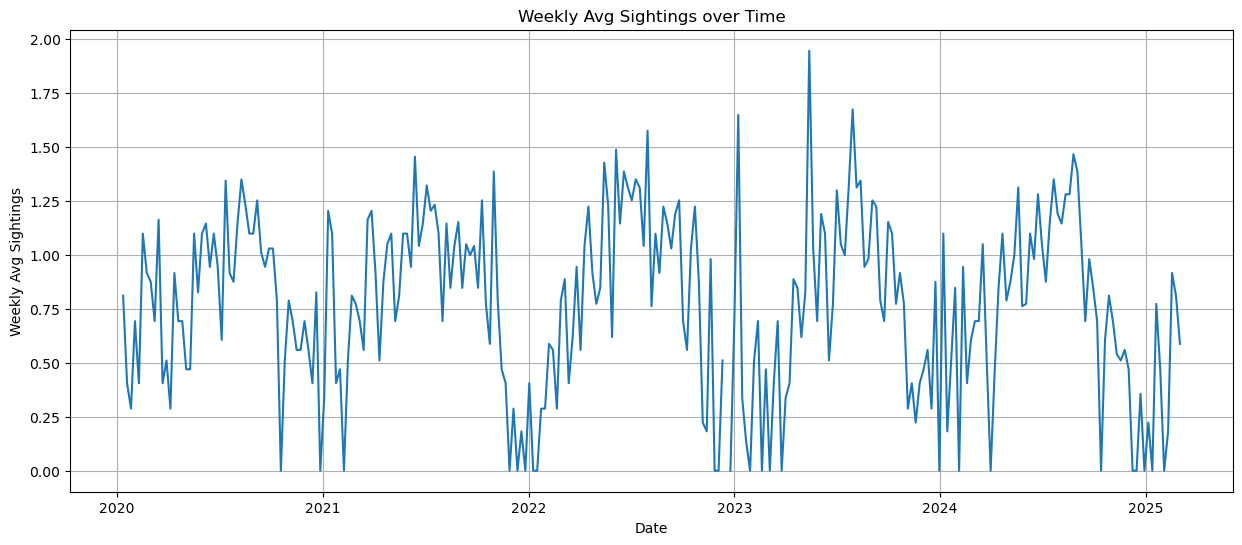

In [52]:
df = rs_weekly.copy()

df["ds"] = pd.to_datetime(df["ds"])

plt.figure(figsize=(15,6))
plt.plot(df["ds"], np.log(df["y"]))

plt.xlabel("Date")
plt.ylabel("Weekly Avg Sightings")
plt.title("Weekly Avg Sightings over Time")
plt.grid(True)

plt.show()

In [53]:
import torch
from torch.serialization import load as _real_torch_load

torch.load = lambda *args, **kwargs: _real_torch_load(
    *args, **{**kwargs, 'weights_only': False}
)

results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):

    train = rs_weekly.iloc[train_index].copy()
    test = rs_weekly.iloc[test_index].copy()
    train = train.dropna(subset=["y"])

    model = NeuralProphet(
        yearly_seasonality=True,
        weekly_seasonality=False,  # no sub-weekly patterns in weekly data
        epochs=40,
        accelerator='cpu',
        n_lags=4                   # 4 weekly lags ≈ 1 month
    )

    model = model.add_country_holidays(country_name="US")
    model.add_lagged_regressor('apparent_temperature_max', n_lags=4)  # 4 weeks

    model.fit(train, freq="W", progress="off")

    future = pd.concat([
        train[['ds', 'y'] + regressed_features],
        test[['ds', 'y']].merge(wd_merged[['ds'] + regressed_features], on="ds", how="left")
    ])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_pred = np.round(y_pred)
    y_true = test["y"].values

    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse_val, "mape": mape_val})

neural_prophet_weekly_results_df = pd.DataFrame(results)
neural_prophet_weekly_results_df.loc["mean"] = ["mean", neural_prophet_weekly_results_df["rmse"].mean(), neural_prophet_weekly_results_df["mape"].mean()]
neural_prophet_weekly_results_df

Finding best initial lr:   0%|          | 0/210 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 11it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/210 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

...

Predicting: 17it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/214 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 17it [00:00, ?it/s]

,fold,rmse,mape
0,0,0.593717,0.279762
1,1,1.169397,0.487341
2,2,2.496079,0.620536
3,3,0.799039,0.317893
4,4,0.920601,0.200529
5,5,1.541058,0.318684
6,6,0.538774,0.187285
7,7,1.006920,0.396592
8,8,0.399653,0.215064
9,9,0.555653,0.334226


In [54]:
# forecast already has the right columns: yhat1, trend, seasonality etc.
print(forecast.columns.tolist())

# Plot directly from forecast (no get_latest_forecast needed)
fig1 = model.plot(forecast)
fig1.show()

# Plot components
fig2 = model.plot_components(forecast)
fig2.show()

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.


['ds', 'y', 'yhat1', 'ar1', 'lagged_regressor_apparent_temperature_max1', 'trend', 'season_yearly', 'events_additive', 'event_Christmas Day', 'event_Christmas Day (observed)', 'event_Columbus Day', 'event_Independence Day', 'event_Independence Day (observed)', 'event_Juneteenth National Independence Day', 'event_Juneteenth National Independence Day (observed)', 'event_Labor Day', 'event_Martin Luther King Jr. Day', 'event_Memorial Day', "event_New Year's Day", "event_New Year's Day (observed)", 'event_Thanksgiving Day', 'event_Veterans Day', 'event_Veterans Day (observed)', "event_Washington's Birthday"]


ERROR - (NP.plotly.plot_components) - plotly-resampler is not installed. Please install it to use the resampler.


In [55]:
model.plot_parameters()

ERROR - (NP.plotly.plot_parameters) - plotly-resampler is not installed. Please install it to use the resampler.
